In [ ]:
'''
Setup and Configuration
- Install required packages: PennyLane, NumPy, PyTorch, torchvision, matplotlib
- Import all necessary libraries for quantum computing and image processing
- Configure image size (16x16) and number of qubits (8)
- 16x16 = 256 pixels maps to 2^8 = 256 quantum amplitudes
'''

%pip install pennylane numpy torch torchvision matplotlib --quiet

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import torch
from torchvision import datasets, transforms

IMAGE_SIZE = 16
N_QUBITS = 8

print(f'{IMAGE_SIZE}x{IMAGE_SIZE} images -> {N_QUBITS} qubits')



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
16x16 images -> 8 qubits


In [ ]:
'''
Load MNIST Dataset
- Resize images from 28x28 to 16x16 pixels
- Convert images to PyTorch tensors
- Download training set (60,000 images)
'''

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])
mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
print(f'Loaded {len(mnist_train)} images')


Loaded 60000 images


In [ ]:
'''
Core Functions
- compute_fidelity: Calculate |<psi1|psi2>|^2 between two quantum states
- preprocess_image: Flatten image tensor and normalize to unit vector
- state_to_mps: Convert state vector to MPS using sequential SVD
  - Reshape state into tensor with one leg per qubit
  - Apply SVD at each bond, optionally truncate to max_bond_dim
  - Store U matrices as MPS tensors, absorb S into remaining tensor
- mps_to_state: Contract MPS tensors back to full state vector
- get_max_bond_dim: Return maximum bond dimension across all MPS tensors
- mps_reconstruct: Full pipeline from image to MPS to reconstruction with fidelity
'''

def compute_fidelity(state1, state2):
    return np.abs(np.vdot(state1, state2)) ** 2

def preprocess_image(image_tensor):
    flat = image_tensor.flatten().numpy()
    if np.allclose(flat, 0):
        flat = np.ones_like(flat)
    return flat / np.linalg.norm(flat)

def state_to_mps(state_vector, n_qubits, max_bond_dim=None):
    tensor = state_vector.reshape([2] * n_qubits)
    mps_tensors = []
    bond_dim = 1
    
    for i in range(n_qubits - 1):
        remaining = n_qubits - i - 1
        matrix = tensor.reshape(bond_dim * 2, 2 ** remaining)
        U, S, Vh = np.linalg.svd(matrix, full_matrices=False)
        
        new_bond = len(S)
        if max_bond_dim is not None:
            new_bond = min(new_bond, max_bond_dim)
        
        mps_tensors.append(U[:, :new_bond].reshape(bond_dim, 2, new_bond))
        tensor = np.diag(S[:new_bond]) @ Vh[:new_bond, :]
        bond_dim = new_bond
    
    mps_tensors.append(tensor.reshape(bond_dim, 2, 1))
    return mps_tensors

def mps_to_state(mps_tensors):
    result = mps_tensors[0]
    for tensor in mps_tensors[1:]:
        result = np.tensordot(result, tensor, axes=([-1], [0]))
    return result.squeeze().flatten()

def get_max_bond_dim(mps_tensors):
    return max([t.shape[2] for t in mps_tensors])

def mps_reconstruct(image_tensor, n_qubits, max_bond_dim=None):
    state = preprocess_image(image_tensor)
    mps = state_to_mps(state, n_qubits, max_bond_dim)
    recon = mps_to_state(mps)
    recon = recon / np.linalg.norm(recon)
    return np.abs(recon).reshape(IMAGE_SIZE, IMAGE_SIZE), compute_fidelity(state, recon), get_max_bond_dim(mps)


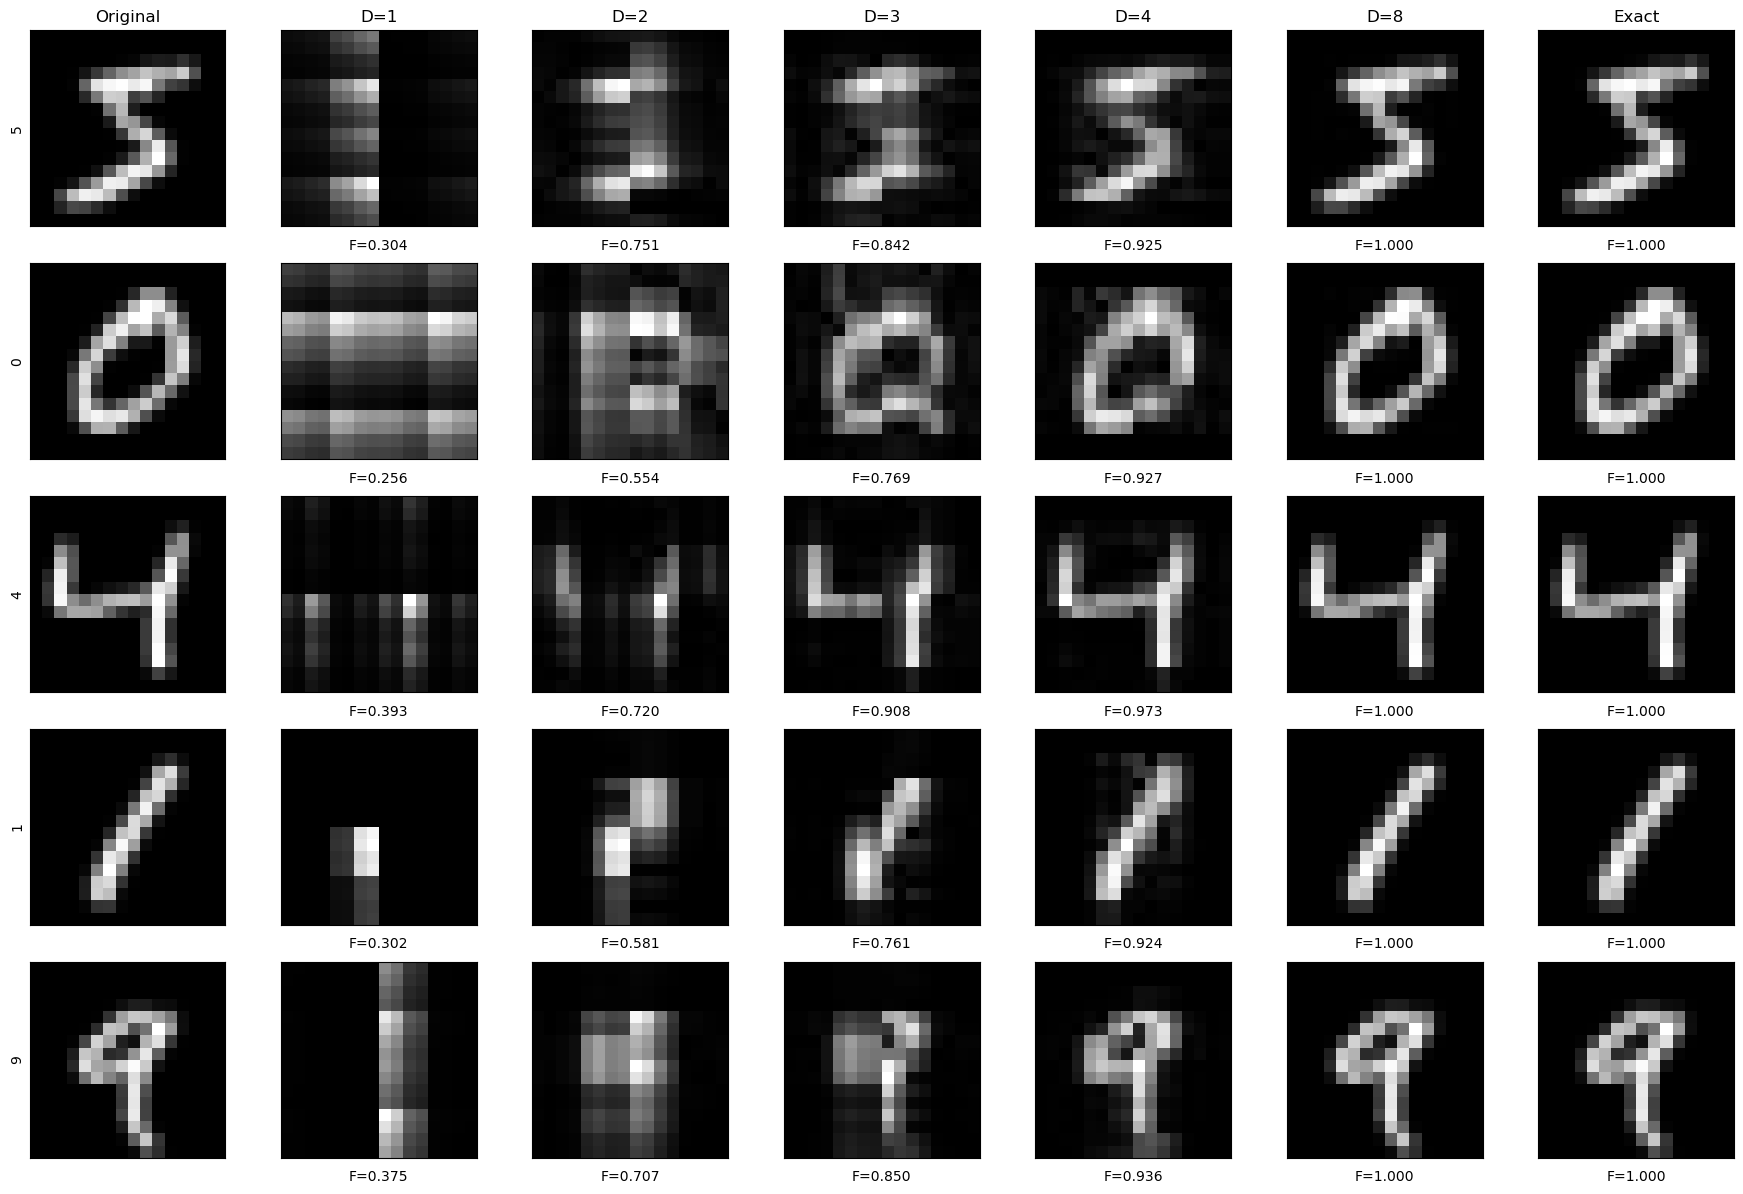

In [ ]:
'''
MPS Reconstruction Visualization (Figure 3 from paper)
- Display 5 MNIST digits with reconstructions at different bond dimensions
- Bond dimensions tested: D=1, 2, 3, 4, 8, and Exact (no truncation)
- Shows fidelity (F) for each reconstruction
- Demonstrates tradeoff: lower D = simpler representation but lower fidelity
'''

n_images = 5
bond_dims = [1, 2, 3, 4, 8, None]

fig, axes = plt.subplots(n_images, len(bond_dims) + 1, figsize=(18, 12))

for row in range(n_images):
    img, label = mnist_train[row]
    original = img.squeeze().numpy()
    original_norm = original / np.linalg.norm(original.flatten())
    
    axes[row, 0].imshow(np.abs(original_norm), cmap='gray')
    if row == 0:
        axes[row, 0].set_title('Original')
    axes[row, 0].set_ylabel(f'{label}')
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    
    for col, max_D in enumerate(bond_dims):
        recon, fid, actual_D = mps_reconstruct(img, N_QUBITS, max_bond_dim=max_D)
        axes[row, col + 1].imshow(recon, cmap='gray')
        if row == 0:
            axes[row, col + 1].set_title('Exact' if max_D is None else f'D={max_D}')
        axes[row, col + 1].set_xticks([])
        axes[row, col + 1].set_yticks([])
        axes[row, col + 1].text(0.5, -0.12, f'F={fid:.3f}', transform=axes[row, col + 1].transAxes, ha='center')

plt.tight_layout()
plt.show()


In [ ]:
'''
MPS to Unitary Conversion (Paper's Key Contribution)
- get_bond_dimensions: Extract bond dimensions [D_0, D_1, ..., D_n] from MPS
- get_n_ancilla: Calculate number of ancilla qubits needed (ceil(log2(max_D)))
- mps_tensor_to_unitary: Convert single MPS tensor to unitary matrix
  - For n_ancilla=0: Create 2x2 unitary from normalized vector
  - For n_ancilla>0: Build isometry from MPS tensor, extend to unitary via QR
  - Output acts on (physical qubit) x (ancilla register)
  - Ensures unitarity via SVD polar decomposition
'''

def get_bond_dimensions(mps_tensors):
    dims = [mps_tensors[0].shape[0]]
    for tensor in mps_tensors:
        dims.append(tensor.shape[2])
    return dims

def get_n_ancilla(mps_tensors):
    max_D = get_max_bond_dim(mps_tensors)
    if max_D <= 1:
        return 0
    return int(np.ceil(np.log2(max_D)))

def mps_tensor_to_unitary(tensor, n_ancilla):
    D_left, d, D_right = tensor.shape
    
    if n_ancilla == 0:
        vec = tensor.flatten()
        vec = vec / np.linalg.norm(vec)
        U = np.zeros((2, 2), dtype=complex)
        U[:, 0] = vec
        if np.abs(vec[0]) > np.abs(vec[1]):
            ortho = np.array([-np.conj(vec[1]), np.conj(vec[0])])
        else:
            ortho = np.array([np.conj(vec[1]), -np.conj(vec[0])])
        U[:, 1] = ortho / np.linalg.norm(ortho)
        return U
    
    ancilla_dim = 2 ** n_ancilla
    total_dim = 2 * ancilla_dim
    
    # Build isometry from MPS tensor
    isometry = np.zeros((total_dim, D_left), dtype=complex)
    for a_in in range(D_left):
        for p_out in range(2):
            for a_out in range(D_right):
                out_idx = p_out * ancilla_dim + a_out
                isometry[out_idx, a_in] = tensor[a_in, p_out, a_out]
    
    # Normalize columns
    for j in range(D_left):
        norm = np.linalg.norm(isometry[:, j])
        if norm > 1e-10:
            isometry[:, j] /= norm
    
    # Extend to unitary via QR
    Q, R = np.linalg.qr(isometry, mode='complete')
    
    full_unitary = Q.copy()
    for j in range(min(D_left, total_dim)):
        if np.abs(R[j, j]) > 1e-10:
            phase = R[j, j] / np.abs(R[j, j])
            full_unitary[:, j] = Q[:, j] * phase
    
    final_U = np.eye(total_dim, dtype=complex)
    for a_in in range(D_left):
        final_U[:, a_in] = full_unitary[:, a_in]
    
    remaining = list(range(D_left, total_dim))
    for in_idx in range(total_dim):
        a_in = in_idx % ancilla_dim
        p_in = in_idx // ancilla_dim
        if p_in == 0 and a_in < D_left:
            continue
        if remaining:
            final_U[:, in_idx] = Q[:, remaining.pop(0)]
    
    # Ensure unitarity
    U, S, Vh = np.linalg.svd(final_U, full_matrices=False)
    return U @ Vh


In [ ]:
'''
Build MPS Quantum Circuit
- build_mps_circuit: Construct PennyLane circuit from MPS unitaries
  - Each unitary acts on physical qubit i + ancilla register
  - Returns circuit function and total qubit count
- extract_physical_state: Post-select on ancilla qubits in |0> state
  - Extract amplitudes where ancilla indices are 0
  - Return normalized physical state and success probability
'''

def build_mps_circuit(mps_tensors, n_physical, n_ancilla):
    total_qubits = n_physical + max(1, n_ancilla)
    
    if n_ancilla == 0:
        dev = qml.device('default.qubit', wires=n_physical)
        unitaries = [mps_tensor_to_unitary(t, 0) for t in mps_tensors]
        
        @qml.qnode(dev)
        def circuit():
            for i, U in enumerate(unitaries):
                qml.QubitUnitary(U, wires=[i])
            return qml.state()
        return circuit, n_physical
    
    dev = qml.device('default.qubit', wires=total_qubits)
    unitaries = [mps_tensor_to_unitary(t, n_ancilla) for t in mps_tensors]
    
    @qml.qnode(dev)
    def circuit():
        for i, U in enumerate(unitaries):
            wires = [i] + list(range(n_physical, total_qubits))
            qml.QubitUnitary(U, wires=wires)
        return qml.state()
    
    return circuit, total_qubits

def extract_physical_state(full_state, n_physical, n_ancilla):
    if n_ancilla == 0:
        return full_state, 1.0
    
    physical_dim = 2 ** n_physical
    ancilla_dim = 2 ** n_ancilla
    
    physical_state = np.zeros(physical_dim, dtype=complex)
    for i in range(physical_dim):
        physical_state[i] = full_state[i * ancilla_dim]
    
    norm = np.linalg.norm(physical_state)
    if norm > 0:
        physical_state /= norm
    return physical_state, norm ** 2


In [ ]:
'''
Test MPS-Based Quantum Circuit
- test_mps_circuit: Full pipeline test for image encoding
  - Preprocess image to quantum state vector
  - Convert to MPS with optional bond dimension truncation
  - Build quantum circuit from MPS unitaries
  - Execute circuit and extract physical state via post-selection
  - Return fidelity, success probability, and circuit parameters
'''

def test_mps_circuit(image_tensor, n_qubits, max_bond_dim=None, verbose=True):
    state = preprocess_image(image_tensor)
    mps = state_to_mps(state, n_qubits, max_bond_dim)
    
    bond_dims = get_bond_dimensions(mps)
    max_D = get_max_bond_dim(mps)
    n_ancilla = get_n_ancilla(mps)
    
    if verbose:
        print(f'Bond dims: {bond_dims}, max D={max_D}, ancilla={n_ancilla}')
    
    circuit, total_qubits = build_mps_circuit(mps, n_qubits, n_ancilla)
    full_state = circuit()
    physical_state, success_prob = extract_physical_state(full_state, n_qubits, n_ancilla)
    
    mps_state = mps_to_state(mps)
    mps_state = mps_state / np.linalg.norm(mps_state)
    
    fid_mps = compute_fidelity(mps_state, physical_state)
    fid_orig = compute_fidelity(state, physical_state)
    
    if verbose:
        print(f'Fidelity vs MPS: {fid_mps:.4f}, vs original: {fid_orig:.4f}, success prob: {success_prob:.4f}')
    
    return {'fidelity': fid_orig, 'success_prob': success_prob, 'max_D': max_D, 'n_ancilla': n_ancilla}

# Test
test_img, label = mnist_train[0]
print(f'Testing digit {label}:')
result = test_mps_circuit(test_img, N_QUBITS)


Testing digit 5:
Bond dims: [1, 2, 4, 8, 16, 8, 4, 2, 1], max D=16, ancilla=4
Fidelity vs MPS: 0.1758, vs original: 0.1758, success prob: 0.8750


In [ ]:
'''
Test at Different Bond Dimensions
- Compare circuit performance at D=2, 4, 8, and Exact
- Shows tradeoff between bond dimension and fidelity
- Lower D requires fewer ancilla qubits but gives lower fidelity
'''

print('Testing at different bond dimensions:')
for max_D in [2, 4, 8, None]:
    result = test_mps_circuit(test_img, N_QUBITS, max_bond_dim=max_D, verbose=False)
    D_str = 'Exact' if max_D is None else f'D={max_D}'
    print(f'{D_str}: F={result["fidelity"]:.4f}, ancilla={result["n_ancilla"]}, success={result["success_prob"]:.4f}')


Testing at different bond dimensions:
D=2: F=0.2660, ancilla=1, success=1.0000
D=4: F=0.2399, ancilla=2, success=1.0000
D=8: F=0.2464, ancilla=3, success=1.0000
Exact: F=0.1758, ancilla=4, success=0.8750


In [ ]:
'''
Test on Multiple Images
- Run MPS circuit encoding on first 5 MNIST images
- Use fixed bond dimension D=8
- Report fidelity for each digit
'''

print('Testing on first 5 images (D=8):')
for i in range(5):
    img, label = mnist_train[i]
    result = test_mps_circuit(img, N_QUBITS, max_bond_dim=8, verbose=False)
    print(f'Image {i} (digit {label}): F={result["fidelity"]:.4f}')


Testing on first 5 images (D=8):
Image 0 (digit 5): F=0.2464
Image 1 (digit 0): F=0.2586
Image 2 (digit 4): F=0.1488
Image 3 (digit 1): F=0.3499
Image 4 (digit 9): F=0.2099


In [ ]:
'''
Visualize Circuit Structure
- Use smaller 4x4 image (4 qubits) for readable circuit diagram
- Apply bond dimension D=2 truncation
- Draw circuit showing sequential unitary gates
- Each U_i acts on physical qubit i and shared ancilla register
'''

small_transform = transforms.Compose([transforms.Resize((4, 4)), transforms.ToTensor()])
small_mnist = datasets.MNIST(root='./data', train=True, download=True, transform=small_transform)
small_img, _ = small_mnist[0]

state = preprocess_image(small_img)
mps = state_to_mps(state, 4, max_bond_dim=2)
n_ancilla = get_n_ancilla(mps)

dev = qml.device('default.qubit', wires=4 + n_ancilla)
unitaries = [mps_tensor_to_unitary(t, n_ancilla) for t in mps]

@qml.qnode(dev)
def demo_circuit():
    for i, U in enumerate(unitaries):
        wires = [i] + list(range(4, 4 + n_ancilla))
        qml.QubitUnitary(U, wires=wires)
    return qml.state()

print('Circuit structure (4x4 image, D=2):')
print(qml.draw(demo_circuit)())


Circuit structure (4x4 image, D=2):
0: ─╭U(M0)──────────────────────┤  State
1: ─│──────╭U(M1)───────────────┤  State
2: ─│──────│──────╭U(M2)────────┤  State
3: ─│──────│──────│──────╭U(M3)─┤  State
4: ─╰U(M0)─╰U(M1)─╰U(M2)─╰U(M3)─┤  State

M0 = 
[[-0.46810983+0.j -0.5299747 +0.j -0.5299747 +0.j  0.46810983+0.j]
 [-0.5299747 +0.j  0.80868381+0.j -0.19131619+0.j  0.16898352+0.j]
 [-0.5299747 +0.j -0.19131619+0.j  0.80868381+0.j  0.16898352+0.j]
 [ 0.46810983+0.j  0.16898352+0.j  0.16898352+0.j  0.85074222+0.j]]
M1 = 
[[-0.497783  +0.j -0.0841407 +0.j -0.83531789+0.j -0.21766131+0.j]
 [ 0.4375884 +0.j -0.2821838 +0.j -0.4252476 +0.j  0.74030613+0.j]
 [-0.5681017 +0.j -0.70120606+0.j  0.34037399+0.j  0.26403799+0.j]
 [-0.4878411 +0.j  0.6493094 +0.j  0.07452547+0.j  0.57866599+0.j]]
M2 = 
[[-0.42010393+0.j -0.63608451+0.j -0.50499657+0.j -0.40483039+0.j]
 [ 0.56975387+0.j  0.36950312+0.j -0.59710818+0.j -0.4269775 +0.j]
 [-0.55260094+0.j  0.55219799+0.j  0.22954987+0.j -0.58053117+0.j]
 